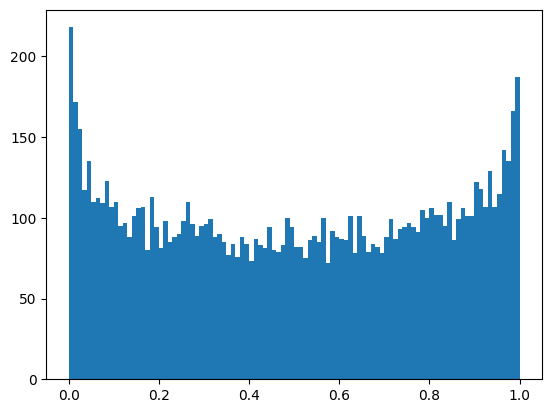

In [1]:
import torch
import torch.distributions as D
def sample_t_u_shaped(n, alpha=0.8, reweight=True, eps=1e-6):
    # U-shaped proposal
    dist = D.Beta(alpha, alpha)
    t = dist.sample((n,)).clamp(eps, 1-eps)

    if reweight:
        # target p(t) = Uniform[0,1] => p(t)=1 on [0,1]
        # importance weight w(t) = p(t)/q(t) = 1 / q(t)
        q = torch.exp(dist.log_prob(t))
        w = (1.0 / q)
        w = w / w.mean()          # stabilize; keeps expected weight = 1
    else:
        w = torch.ones_like(t)

    return t, w

import matplotlib.pyplot as plt

t, _ = sample_t_u_shaped(10000)
_ = plt.hist(t.numpy(), bins=100)

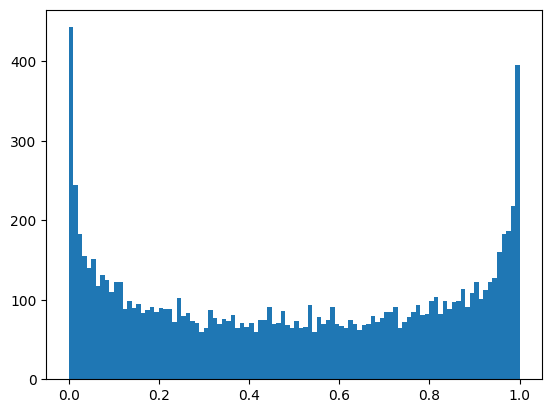

In [2]:

t, _ = sample_t_u_shaped(10000, alpha=0.6)
_ = plt.hist(t.numpy(), bins=100)

In [ ]:
# import torch

# def hungarian_gpu_v2(cost_matrix: torch.Tensor, eps: float = 1e-6, max_iter: int = None) -> torch.Tensor:
#     """
#     Batched exact linear assignment on GPU.
#     Runs LAPJV (Jonker-Volgenant) independently per batch element.
#     Correct, no vectorization-across-batch bugs.

#     Args:
#         cost_matrix: [B, N, N] float32/float64
#     Returns:
#         assignment:  LongTensor [B, N], assignment[b, i] = j
#     """
#     B, N, _ = cost_matrix.shape
#     device  = cost_matrix.device
#     results = torch.empty(B, N, dtype=torch.long, device=device)

#     for b in range(B):
#         results[b] = _lapjv_single(cost_matrix[b])

#     return results


# def _lapjv_single(C: torch.Tensor) -> torch.Tensor:
#     """
#     LAPJV on a single [N, N] cost matrix.
#     Classic successive shortest path with Dijkstra + potentials.
#     Returns LongTensor [N]: assignment[i] = j.
#     """
#     N      = C.shape[0]
#     device = C.device
#     dtype  = C.dtype
#     INF    = torch.finfo(dtype).max / 2.0

#     # Pad to (N+1) — row/col 0 are dummies
#     M  = N + 1
#     Cp = torch.full((M, M), 0.0, device=device, dtype=dtype)
#     Cp[1:, 1:] = C

#     u   = torch.zeros(M, device=device, dtype=dtype)   # row potentials
#     v   = torch.zeros(M, device=device, dtype=dtype)   # col potentials
#     p   = torch.zeros(M, device=device, dtype=torch.long)  # p[j] = row owning col j
#     way = torch.zeros(M, device=device, dtype=torch.long)  # way[j] = prev col in path

#     for i in range(1, M):
#         p[0] = i
#         j0   = torch.tensor(0, device=device, dtype=torch.long)

#         dist = torch.full((M,), INF, device=device, dtype=dtype)
#         dist[0] = 0.0
#         used = torch.zeros(M, dtype=torch.bool, device=device)

#         # Dijkstra
#         while True:
#             used[j0] = True
#             i0     = p[j0]
#             delta  = INF
#             j1     = torch.tensor(0, device=device, dtype=torch.long)

#             for j in range(1, M):
#                 if not used[j]:
#                     val = Cp[i0, j] - u[i0] - v[j] + dist[j0]
#                     if val < dist[j]:
#                         dist[j] = val
#                         way[j]  = j0
#                     if dist[j] < delta:
#                         delta = dist[j]
#                         j1    = torch.tensor(j, device=device, dtype=torch.long)

#             j0 = j1
#             if used[j1]:
#                 break
#             if p[j1] == 0:   # j1 is unassigned → path found
#                 used[j1] = True
#                 break

#         # Update potentials
#         for j in range(1, M):
#             if used[j]:
#                 u[p[j]] += dist[j] - dist[j0] if j != j0.item() else 0.0
#                 v[j]    -= dist[j] - dist[j0] if j != j0.item() else 0.0
#         u[i0] += dist[j0] - dist[0]  # correct u for row i0

#         # Augment path
#         j_cur = j0
#         while j_cur != 0:
#             j_prev    = way[j_cur]
#             p[j_cur]  = p[j_prev]
#             j_cur     = j_prev

#     # Extract: p[j] = row owning col j → invert
#     row_ass = torch.zeros(N, dtype=torch.long, device=device)
#     for j in range(1, M):
#         if p[j] > 0:
#             row_ass[p[j] - 1] = j - 1   # back to 0-indexed

#     return row_ass

In [ ]:
# import torch

# def hungarian_gpu_v2(cost_matrix: torch.Tensor, eps: float = 1e-6, max_iter: int = None) -> torch.Tensor:
#     B, N, _ = cost_matrix.shape
#     device  = cost_matrix.device
#     results = torch.empty(B, N, dtype=torch.long, device=device)
#     for b in range(B):
#         results[b] = _lapjv_single(cost_matrix[b])
#     return results


# def _lapjv_single(C: torch.Tensor) -> torch.Tensor:
#     """
#     LAPJV on a single [N, N] cost matrix.
#     Successive shortest path with Dijkstra — bounded inner loop, no cycles.
#     """
#     N      = C.shape[0]
#     device = C.device
#     dtype  = C.dtype
#     INF    = torch.finfo(dtype).max / 2.0

#     # Pad to (N+1): row/col 0 are dummies
#     M  = N + 1
#     Cp = torch.zeros(M, M, device=device, dtype=dtype)
#     Cp[1:, 1:] = C

#     u   = torch.zeros(M, device=device, dtype=dtype)        # row potentials
#     v   = torch.zeros(M, device=device, dtype=dtype)        # col potentials
#     p   = torch.zeros(M, device=device, dtype=torch.long)   # p[j] = row owning col j
#     way = torch.zeros(M, device=device, dtype=torch.long)   # way[j] = prev col in path

#     for i in range(1, M):
#         p[0] = i

#         dist = torch.full((M,), INF, device=device, dtype=dtype)
#         dist[0] = 0.0
#         used = torch.zeros(M, dtype=torch.bool, device=device)

#         # ── Dijkstra: exactly M iterations, one column settled per step ───
#         j0 = 0
#         for _ in range(M):                        # ← bounded, never cycles
#             used[j0] = True

#             i0        = p[j0].item()
#             best_val  = INF
#             j1        = -1

#             for j in range(1, M):
#                 if not used[j]:
#                     # reduced cost from current col j0 to col j via row i0
#                     val = Cp[i0, j].item() - u[i0].item() - v[j].item() + dist[j0].item()
#                     if val < dist[j].item():
#                         dist[j]  = val
#                         way[j]   = j0
#                     if dist[j].item() < best_val:
#                         best_val = dist[j].item()
#                         j1       = j

#             if j1 == -1:
#                 break               # all reachable columns visited

#             j0 = j1

#             if p[j0].item() == 0:  # j0 is unassigned → shortest path found
#                 break

#         # ── Update potentials ─────────────────────────────────────────────
#         j = j0
#         while j != 0:
#             pj       = p[j].item()
#             v[j]    -= dist[j0].item() - dist[way[j]].item() if way[j] != 0 else dist[j0].item()
#             u[pj]   += dist[j0].item() - dist[j].item()
#             j        = way[j].item()

#         # simpler, numerically equivalent potential update:
#         for j in range(1, M):
#             if used[j]:
#                 v[j] += dist[j].item() - dist[j0].item()
#         u[i] = -dist[j0].item()

#         # ── Augment path ──────────────────────────────────────────────────
#         j_cur = j0
#         while j_cur != 0:
#             j_prev   = way[j_cur].item()
#             p[j_cur] = p[j_prev]
#             j_cur    = j_prev

#     # ── Extract 0-indexed assignment ──────────────────────────────────────
#     row_ass = torch.zeros(N, dtype=torch.long, device=device)
#     for j in range(1, M):
#         if p[j].item() > 0:
#             row_ass[p[j].item() - 1] = j - 1

#     return row_ass

In [2]:
from torch_linear_assignment import batch_linear_assignment
import torch
def hungarian_gpu_v2(cost_matrix: torch.Tensor, **kwargs) -> torch.Tensor:
    return batch_linear_assignment(cost_matrix)   # stays on GPU, CUDA kernel

In [3]:
def test_known_assignment():
    # Identity permutation: cheapest to assign i→i
    B, N = 2, 4
    cost = torch.eye(N).unsqueeze(0).expand(B, -1, -1) * 0.01
    # Add high cost to off-diagonal
    cost = cost + (1 - torch.eye(N)).unsqueeze(0).expand(B, -1, -1) * 100.0

    assign = hungarian_gpu_v2(cost)
    expected = torch.arange(N).unsqueeze(0).expand(B, -1)
    assert torch.all(assign == expected), f"Expected identity, got {assign}"
    print("✓ Known assignment")

test_known_assignment()

✓ Known assignment


In [4]:
def test_permutation_assignment():
    # Known shuffled permutation
    B, N = 3, 5
    perm = torch.tensor([2, 4, 0, 3, 1])  # ground truth assignment
    cost = torch.full((B, N, N), 100.0)
    for i, j in enumerate(perm):
        cost[:, i, j] = 0.0

    assign = hungarian_gpu_v2(cost)
    assert torch.all(assign == perm.unsqueeze(0).expand(B, -1))
    print("✓ Permutation assignment")

test_permutation_assignment()

✓ Permutation assignment


In [5]:
def test_bijection(B=8, N=64):
    cost = torch.rand(B, N, N)
    assign = hungarian_gpu_v2(cost)

    for b in range(B):
        assigned = assign[b]
        # No unassigned entries
        assert (assigned >= 0).all(), "Found unassigned rows"
        # All targets are unique (bijection)
        assert assigned.unique().numel() == N, f"Duplicate assignments in batch {b}"
        # All indices in valid range
        assert assigned.max() < N and assigned.min() >= 0

    print("✓ Bijection valid")

test_bijection()  

✓ Bijection valid


In [15]:
from scipy.optimize import linear_sum_assignment
import numpy as np

def hungarian_gpu_scipy(cost_matrix: torch.Tensor, **kwargs) -> torch.Tensor:
    C = cost_matrix.detach().cpu().numpy()
    B, N, _ = C.shape
    out = torch.empty(B, N, dtype=torch.long)
    for b in range(B):
        _, col = linear_sum_assignment(C[b])
        out[b] = torch.from_numpy(col)
    return out.to(cost_matrix.device)

In [6]:
def test_vs_scipy(B=16, N=32, tol=1e-3):
    cost = torch.rand(B, N, N)
    assign_gpu = hungarian_gpu_v2(cost)          # drop eps= — current impl ignores it

    for b in range(B):
        C = cost[b].cpu().numpy()
        _, col_ref = linear_sum_assignment(C)
        
        cost_gpu = C[np.arange(N), assign_gpu[b].cpu().numpy()].sum()  # add .cpu()
        cost_ref = C[np.arange(N), col_ref].sum()

        assert abs(cost_gpu - cost_ref) < tol, (
            f"Batch {b}: GPU cost {cost_gpu:.4f} vs scipy {cost_ref:.4f}"
        )

    print("✓ Matches scipy within tolerance")

In [7]:
def test_reorder():
    B, N, C = 4, 8, 3

    # Ground truth: x1 is just x0 with a known permutation applied
    x0 = torch.rand(B, N, C)
    
    # Create a different random permutation per batch
    perms = torch.stack([torch.randperm(N) for _ in range(B)])  # [B, N]
    x1 = x0[torch.arange(B).unsqueeze(1).expand(B, N), perms]  # [B, N, C]

    # Recover the permutation
    assignment = hungarian_gpu_v2(torch.cdist(x0, x1))
    x1_reordered = x1[torch.arange(B).unsqueeze(1).expand(B, N), assignment]

    # x1_reordered should now equal x0 exactly
    assert torch.allclose(x1_reordered, x0, atol=1e-5), \
        f"Max error: {(x1_reordered - x0).abs().max():.6f}"

    print("✓ Reorder test passed")

test_reorder()

✓ Reorder test passed
